# Lecture 19 — Sequence Models and Recurrent Networks

**CMU 10-414/714, Deep Learning Systems (lecture by Zico Kolter)**
Companion notebook · Sangram Lembe

Everything so far assumed independent examples. Sequences break that: the order *is* the information.
This notebook builds a recurrent network and an LSTM from scratch on the needle-style autodiff engine,
and measures the lecture's claims:

1. the hidden state really depends on every earlier input — and no later one
2. backprop through time is just one `backward()` call
3. activations explode or vanish when one matrix is applied over and over
4. an LSTM keeps the influence of early inputs alive far longer than a plain RNN

In [1]:
import numpy as np

class Tensor:
    """A needle-style tensor: data plus the op and inputs that produced it."""

    def __init__(self, array, requires_grad=True):
        self._init(None, [], np.asarray(array, dtype=np.float64), requires_grad)

    def _init(self, op, inputs, cached, requires_grad):
        self.op, self.inputs = op, list(inputs)
        self.cached, self.requires_grad, self.grad = cached, requires_grad, None

    @classmethod
    def make_const(cls, array):
        """A leaf with no history - what detach() returns."""
        t = Tensor.__new__(Tensor)
        t._init(None, [], array, False)
        return t

    @staticmethod
    def make_from_op(op, inputs):
        out = op.compute(*[i.cached for i in inputs])
        if not any(i.requires_grad for i in inputs):
            return Tensor.make_const(out)        # nothing needs a gradient: no graph
        t = Tensor.__new__(Tensor)
        t._init(op, inputs, out, True)
        return t

    # .data is a detached view that SHARES memory; assigning to it updates in place
    @property
    def data(self):
        return Tensor.make_const(self.cached)
    @data.setter
    def data(self, value):
        self.cached = value.cached if isinstance(value, Tensor) else np.asarray(value)

    def detach(self):  return self.data
    def numpy(self):   return self.cached
    shape = property(lambda s: s.cached.shape)
    def __repr__(self):
        return f"Tensor({np.array2string(self.cached, precision=4)}, op={type(self.op).__name__ if self.op else None})"

    def __add__(s, o):  return EAdd()(s, o) if isinstance(o, Tensor) else AddS(o)(s)
    def __mul__(s, o):  return EMul()(s, o) if isinstance(o, Tensor) else MulS(o)(s)
    def __neg__(s):     return MulS(-1.0)(s)
    def __sub__(s, o):  return s + (-o)
    def __rsub__(s, o): return (-s) + o
    def __pow__(s, c):  return PowS(c)(s)
    def __truediv__(s, o):
        return s * (o ** -1.0) if isinstance(o, Tensor) else MulS(1.0 / o)(s)
    def __matmul__(s, o): return MatMul()(s, o)
    __radd__, __rmul__ = __add__, __mul__

    def backward(self):
        backprop(self, Tensor.make_const(np.ones_like(self.cached)))


class Op:
    def __call__(self, *ins):
        return Tensor.make_from_op(self, ins)
    def grads(self, g, node):
        r = self.gradient(g, node)
        return r if isinstance(r, tuple) else (r,)

class EAdd(Op):
    def compute(s, a, b): return a + b
    def gradient(s, g, n): return g, g
class AddS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a + s.c
    def gradient(s, g, n): return g
class EMul(Op):
    def compute(s, a, b): return a * b
    def gradient(s, g, n): return g * n.inputs[1], g * n.inputs[0]
class MulS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a * s.c
    def gradient(s, g, n): return g * s.c
class PowS(Op):
    def __init__(s, c): s.c = c
    def compute(s, a): return a ** s.c
    def gradient(s, g, n): return g * (n.inputs[0] ** (s.c - 1)) * s.c
class MatMul(Op):
    def compute(s, a, b): return a @ b
    def gradient(s, g, n):
        return g @ transpose(n.inputs[1]), transpose(n.inputs[0]) @ g
class Transpose(Op):
    def compute(s, a): return a.T
    def gradient(s, g, n): return transpose(g)
class Reshape(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return a.reshape(s.shape)
    def gradient(s, g, n): return reshape(g, n.inputs[0].shape)
class BroadcastTo(Op):
    def __init__(s, shape): s.shape = shape
    def compute(s, a): return np.broadcast_to(a, s.shape).copy()
    def gradient(s, g, n):                        # broadcast forward = sum backward
        ins = n.inputs[0].shape
        pad = len(s.shape) - len(ins)
        axes = tuple(range(pad)) + tuple(pad + i for i, d in enumerate(ins)
                                         if d == 1 and s.shape[pad + i] != 1)
        return reshape(summation(g, axes) if axes else g, ins)
class Summation(Op):
    def __init__(s, axes=None):
        s.axes = (axes,) if isinstance(axes, int) else axes
    def compute(s, a): return a.sum(axis=s.axes)
    def gradient(s, g, n):
        ins = n.inputs[0].shape
        ax = range(len(ins)) if s.axes is None else s.axes
        keep = tuple(1 if i in ax else d for i, d in enumerate(ins))
        return broadcast_to(reshape(g, keep), ins)
class ReLUOp(Op):
    def compute(s, a): return np.maximum(0, a)
    def gradient(s, g, n):
        return g * Tensor.make_const((n.inputs[0].cached > 0) * 1.0)
class Exp(Op):
    def compute(s, a): return np.exp(a)
    def gradient(s, g, n): return g * exp(n.inputs[0])
class LogSumExp(Op):
    """Stable log-sum-exp over axis 1: subtract the row max first."""
    def compute(s, a):
        m = a.max(1, keepdims=True)
        return (np.log(np.exp(a - m).sum(1, keepdims=True)) + m)[:, 0]
    def gradient(s, g, n):
        z = n.inputs[0]
        sm = exp(z - broadcast_to(reshape(n, (z.shape[0], 1)), z.shape))
        return broadcast_to(reshape(g, (z.shape[0], 1)), z.shape) * sm

transpose    = lambda a: Transpose()(a)
reshape      = lambda a, s: Reshape(s)(a)
broadcast_to = lambda a, s: BroadcastTo(s)(a)
summation    = lambda a, axes=None: Summation(axes)(a)
relu         = lambda a: ReLUOp()(a)
exp          = lambda a: Exp()(a)
logsumexp    = lambda a: LogSumExp()(a)

def topo_sort(root):
    """Post-order DFS, iterative so that very deep graphs cannot overflow the stack."""
    order, seen, stack = [], set(), [(root, False)]
    while stack:
        node, done = stack.pop()
        if done:
            order.append(node)
            continue
        if id(node) in seen:
            continue
        seen.add(id(node))
        stack.append((node, True))
        for i in node.inputs:
            if id(i) not in seen:
                stack.append((i, False))
    return order

def backprop(out, seed):
    """Reverse-mode AD: walk reverse topological order, summing partial adjoints."""
    parts = {id(out): [seed]}
    for node in reversed(topo_sort(out)):
        if id(node) not in parts: continue
        g = parts[id(node)][0]
        for extra in parts[id(node)][1:]:
            g = g + extra
        node.grad = g
        if node.op is not None:
            for inp, p in zip(node.inputs, node.op.grads(g, node)):
                if inp.requires_grad:
                    parts.setdefault(id(inp), []).append(p)

def numeric_grad(f, param, eps=1e-6):
    """Two-sided finite differences of scalar f() w.r.t. every entry of param."""
    g = np.zeros_like(param.cached)
    for idx in np.ndindex(*param.cached.shape):
        old = param.cached[idx]
        param.cached[idx] = old + eps; a = float(f().cached)
        param.cached[idx] = old - eps; b = float(f().cached)
        param.cached[idx] = old
        g[idx] = (a - b) / (2 * eps)
    return g



class Tanh(Op):
    def compute(s, a): return np.tanh(a)
    def gradient(s, g, n): return g * (1.0 - n * n)          # d tanh = 1 - tanh^2
class Sigmoid(Op):
    def compute(s, a): return 1.0 / (1.0 + np.exp(-a))
    def gradient(s, g, n): return g * n * (1.0 - n)          # d sigma = sigma (1 - sigma)
class Slice(Op):
    """Take columns [a:b] of a 2-D tensor - used to split the LSTM's 4d output."""
    def __init__(s, a, b): s.a, s.b = a, b
    def compute(s, x): return x[:, s.a:s.b]
    def gradient(s, g, n):
        full = np.zeros(n.inputs[0].shape); full[:, s.a:s.b] = 1.0
        pad = PadCols(s.a, n.inputs[0].shape[1])
        return pad(g)
class PadCols(Op):
    def __init__(s, a, total): s.a, s.total = a, total
    def compute(s, g):
        out = np.zeros((g.shape[0], s.total)); out[:, s.a:s.a + g.shape[1]] = g; return out
    def gradient(s, g, n): return Slice(s.a, s.a + n.inputs[0].shape[1])(g)
tanh    = lambda a: Tanh()(a)
sigmoid = lambda a: Sigmoid()(a)
cols    = lambda a, i, j: Slice(i, j)(a)

def param(rng, *shape, scale=None):
    scale = scale if scale is not None else 1.0 / np.sqrt(shape[0])
    return Tensor(rng.uniform(-scale, scale, shape))

class RNNCell:
    def __init__(self, n, d, rng):
        self.Wx, self.Wh, self.b = param(rng, n, d), param(rng, d, d), Tensor(np.zeros((1, d)))
    def params(self): return [self.Wx, self.Wh, self.b]
    def __call__(self, x, h):
        z = x @ self.Wx + h @ self.Wh
        return tanh(z + broadcast_to(self.b, z.shape))

class LSTMCell:
    def __init__(self, n, d, rng, forget_bias=1.0):
        self.d = d
        self.Wx, self.Wh = param(rng, n, 4 * d), param(rng, d, 4 * d)     # ONE big matrix each
        b = np.zeros((1, 4 * d)); b[0, d:2 * d] = forget_bias              # common trick: start f near 1
        self.b = Tensor(b)
    def params(self): return [self.Wx, self.Wh, self.b]
    def __call__(self, x, state):
        h, c = state
        d = self.d
        z = x @ self.Wx + h @ self.Wh
        z = z + broadcast_to(self.b, z.shape)
        i, f = sigmoid(cols(z, 0, d)), sigmoid(cols(z, d, 2 * d))
        g, o = tanh(cols(z, 2 * d, 3 * d)), sigmoid(cols(z, 3 * d, 4 * d))
        c = c * f + i * g                                                  # the key line
        h = tanh(c) * o
        return h, c

class AdamOpt:
    def __init__(self, params, lr=0.01):
        self.p, self.lr, self.t = params, lr, 0
        self.m = [np.zeros_like(q.cached) for q in params]; self.v = [np.zeros_like(q.cached) for q in params]
    def step(self):
        self.t += 1
        for k, q in enumerate(self.p):
            if q.grad is None: continue
            g = q.grad.cached
            self.m[k] = 0.9 * self.m[k] + 0.1 * g; self.v[k] = 0.999 * self.v[k] + 0.001 * g * g
            q.data = q.cached - self.lr * (self.m[k] / (1 - 0.9 ** self.t)) / (np.sqrt(self.v[k] / (1 - 0.999 ** self.t)) + 1e-8)
            q.grad = None

print('engine, tanh, sigmoid, RNN and LSTM cells ready')

engine, tanh, sigmoid, RNN and LSTM cells ready


## 1. When order matters

A toy memory task used throughout: the input is a stream of random bits, and the target at step $t$ is
the bit from $k$ steps earlier, $y_t = x_{t-k}$. Looking at the current input alone is useless:

In [2]:
def make_batch(rng, B, T, delay):
    x = rng.integers(0, 2, (B, T)).astype(float)
    y = np.zeros((B, T), dtype=int)
    y[:, delay:] = x[:, :-delay]
    return x, y

x, y = make_batch(np.random.default_rng(0), 2000, 30, delay=4)
same_step = np.corrcoef(x[:, 4:].ravel(), y[:, 4:].ravel())[0, 1]
four_back = np.corrcoef(x[:, :-4].ravel(), y[:, 4:].ravel())[0, 1]
print(f"correlation of target with the CURRENT input     : {same_step:+.3f}")
print(f"correlation of target with the input 4 steps back: {four_back:+.3f}")

correlation of target with the CURRENT input     : +0.009
correlation of target with the input 4 steps back: +1.000


A model that sees each step in isolation — as every earlier model in this course did — can do no better
than a coin flip. It needs memory.

## 2. The RNN, and what its hidden state depends on

$h_t = \tanh(W_{hx} x_t + W_{hh} h_{t-1} + b)$. Unroll four steps and ask autodiff how much $h_3$ depends
on each input:

In [3]:
rng = np.random.default_rng(1)
cell = RNNCell(n=3, d=8, rng=rng)
xs = [Tensor(rng.normal(size=(1, 3))) for _ in range(4)]

h = Tensor.make_const(np.zeros((1, 8)))                 # h_0 = 0
hs = []
for x_t in xs:
    h = cell(x_t, h)
    hs.append(h)

summation(hs[2]).backward()                             # differentiate h_3
for t, x_t in enumerate(xs, start=1):
    g = 0.0 if x_t.grad is None else np.linalg.norm(x_t.grad.cached)
    print(f"influence of x_{t} on h_3: {g:.4f}")

influence of x_1 on h_3: 0.1686
influence of x_2 on h_3: 0.1907
influence of x_3 on h_3: 1.1419
influence of x_4 on h_3: 0.0000


$h_3$ depends on $x_1$, $x_2$ and $x_3$ — the hidden state is a running summary of the past — and not at
all on $x_4$, which has not happened yet.

## 3. Backpropagation through time

Train on the memory task with delay 4. The forward pass is the loop from the lecture; autodiff handles
the rest.

In [4]:
def run(kind, delay, steps, d=16, T=20, B=32, seed=0, lr=0.02):
    rng = np.random.default_rng(seed)
    cell = RNNCell(1, d, rng) if kind == "rnn" else LSTMCell(1, d, rng)
    Wy, by = param(rng, d, 2), Tensor(np.zeros((1, 2)))
    opt = AdamOpt(cell.params() + [Wy, by], lr)

    def forward(x, y):
        B_ = x.shape[0]
        h = Tensor.make_const(np.zeros((B_, d)))                       # h_0 = 0
        state = (h, Tensor.make_const(np.zeros((B_, d))))
        loss, correct = None, 0
        for t in range(x.shape[1]):
            x_t = Tensor.make_const(x[:, t:t + 1])
            if kind == "rnn": h = cell(x_t, h)
            else:             state = cell(x_t, state); h = state[0]
            if t >= delay:
                logits = h @ Wy
                logits = logits + broadcast_to(by, logits.shape)
                Y = Tensor.make_const(np.eye(2)[y[:, t]])
                l = summation(logsumexp(logits) - summation(logits * Y, 1)) / B_
                loss = l if loss is None else loss + l                # add up every step's loss
                correct += (logits.cached.argmax(1) == y[:, t]).sum()
        return loss, correct / (B_ * (x.shape[1] - delay))

    history = []
    for s in range(steps):
        x, y = make_batch(rng, B, T, delay)
        loss, _ = forward(x, y)
        loss.backward()                                                # BPTT: one call
        opt.step()
        if s % 50 == 0: history.append(float(loss.cached))
    x, y = make_batch(np.random.default_rng(99), 256, T, delay)
    return forward(x, y)[1], history

acc, hist = run("rnn", delay=4, steps=300)
print("loss every 50 steps:", [round(v, 2) for v in hist])
print(f"test accuracy recalling the bit 4 steps back: {acc:.3f}")

loss every 50 steps: [11.28, 0.03, 0.01, 0.0, 0.0, 0.0]
test accuracy recalling the bit 4 steps back: 1.000


## 4. Exploding and vanishing

An RNN multiplies by the same $W_{hh}$ at every step. With ReLU and an input only at step 1, track the size
of the hidden state for different initial variances:

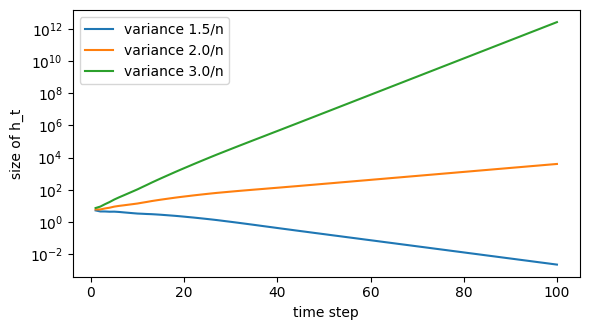

variance 1.5/n: size at step 100 = 2.29e-03
variance 2.0/n: size at step 100 = 4.05e+03
variance 3.0/n: size at step 100 = 2.58e+12


In [5]:
import matplotlib.pyplot as plt

def norms(c, T=100, d=100, seed=0):
    r = np.random.default_rng(seed)
    W = r.normal(0, np.sqrt(c / d), (d, d))
    h = np.maximum(0, r.normal(size=d))
    out = []
    for _ in range(T):
        h = np.maximum(0, W @ h)
        out.append(np.linalg.norm(h))
    return np.array(out)

plt.figure(figsize=(6, 3.4))
for c in (1.5, 2.0, 3.0):
    plt.semilogy(range(1, 101), norms(c), label=f"variance {c}/n")
plt.xlabel("time step"); plt.ylabel("size of h_t"); plt.legend(); plt.tight_layout(); plt.show()
for c in (1.5, 2.0, 3.0):
    print(f"variance {c}/n: size at step 100 = {norms(c)[-1]:.2e}")

$3/n$ explodes to $10^{12}$ and $1.5/n$ vanishes, as in the lecture. Notice that $2/n$ — the value that kept
a deep MLP stable on Day 5 — also drifts here. In an MLP every layer had its own fresh random matrix, so
growth and shrinkage averaged out. An RNN reuses *one* matrix, so whatever that particular matrix does to
a vector gets compounded at every step.

### Bounded activations do not fix vanishing

tanh cannot explode, but it either passes small values or saturates, where its slope collapses:

In [6]:
for z in (0, 1, 2, 3, 5):
    print(f"tanh'({z}) = {1 - np.tanh(z)**2:.4f}")

tanh'(0) = 1.0000
tanh'(1) = 0.4200
tanh'(2) = 0.0707
tanh'(3) = 0.0099
tanh'(5) = 0.0002


## 5. RNN versus LSTM: does early information survive?

Measure the influence of the very first input on the hidden state $T$ steps later, for a tanh RNN and an
LSTM, with fresh random inputs in between:

 steps later         RNN        LSTM
           1     3.7e+00     1.1e+00
           5     7.9e-02     2.3e-01
          10     3.5e-03     4.9e-02
          20     3.4e-06     5.1e-03
          40     1.7e-13     4.2e-05
          80     1.0e-26     1.5e-09


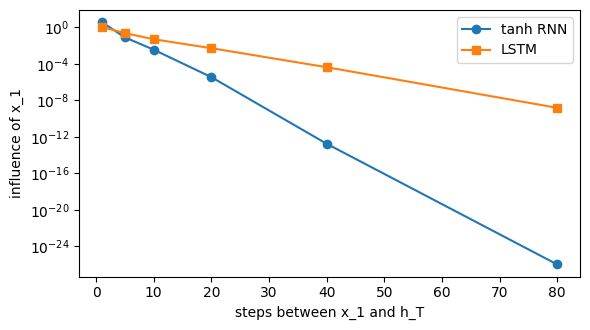

In [7]:
def influence(kind, Ts, d=32, n=8, seed=0):
    rng = np.random.default_rng(seed)
    cell = RNNCell(n, d, rng) if kind == "rnn" else LSTMCell(n, d, rng)
    out = []
    for T in Ts:
        x1 = Tensor(rng.normal(size=(1, n)))
        h = Tensor.make_const(np.zeros((1, d)))
        state = (h, Tensor.make_const(np.zeros((1, d))))
        for t in range(T):
            x_t = x1 if t == 0 else Tensor.make_const(rng.normal(size=(1, n)))
            if kind == "rnn": h = cell(x_t, h)
            else:             state = cell(x_t, state); h = state[0]
        summation(h).backward()
        out.append(np.linalg.norm(x1.grad.cached))
    return np.array(out)

Ts = [1, 5, 10, 20, 40, 80]
rnn_inf, lstm_inf = influence("rnn", Ts), influence("lstm", Ts)
print(f"{'steps later':>12}{'RNN':>12}{'LSTM':>12}")
for T, a, b in zip(Ts, rnn_inf, lstm_inf):
    print(f"{T:>12}{a:>12.1e}{b:>12.1e}")

plt.figure(figsize=(6, 3.4))
plt.semilogy(Ts, rnn_inf, "o-", label="tanh RNN"); plt.semilogy(Ts, lstm_inf, "s-", label="LSTM")
plt.xlabel("steps between x_1 and h_T"); plt.ylabel("influence of x_1"); plt.legend()
plt.tight_layout(); plt.show()

Both decay, but at very different rates: after 40 steps the RNN's dependence on $x_1$ is around $10^{-13}$,
the LSTM's around $10^{-5}$. The reason is the cell update $c_t = c_{t-1}\odot f_t + i_t\odot g_t$. When the
forget gate is near 1, the old cell state passes through with no matrix multiplication at all.

### The extreme case: a perfect memory

Force $f_t = 1$ and $i_t = 0$ by setting their biases very high and very low. Then $c_t = c_{t-1}$
exactly, forever:

In [8]:
rng = np.random.default_rng(3)
lstm = LSTMCell(n=4, d=6, rng=rng)
b = lstm.b.cached.copy()
b[0, 0:6] = -50          # input gate  i -> 0
b[0, 6:12] = 50          # forget gate f -> 1
lstm.b = Tensor(b)
c0 = rng.normal(size=(1, 6))
state = (Tensor.make_const(np.zeros((1, 6))), Tensor.make_const(c0))
for t in range(100):
    state = lstm(Tensor.make_const(rng.normal(size=(1, 4))), state)
print("cell state after 100 steps equals the starting cell state:", np.allclose(state[1].cached, c0))
print("W_hh shape:", lstm.Wh.cached.shape, "-> one 4d-wide matrix, split into i, f, g, o")

cell state after 100 steps equals the starting cell state: True
W_hh shape: (6, 24) -> one 4d-wide matrix, split into i, f, g, o


Real LSTMs learn when to keep and when to forget, rather than being forced either way — but this is the
property that lets information travel far.

## 6. Learning a long memory

Train both on the memory task with longer delays (the sequence is 10 steps longer than the delay).

In [9]:
print(f"{'delay':>6}{'RNN':>8}{'LSTM':>8}")
for delay in (15, 25):
    r_acc, _ = run("rnn", delay, steps=500, T=delay + 10)
    l_acc, _ = run("lstm", delay, steps=500, T=delay + 10)
    print(f"{delay:>6}{r_acc:>8.3f}{l_acc:>8.3f}")

 delay     RNN    LSTM


    15   0.709   0.816


    25   0.673   0.673


At a delay of 15 the LSTM does clearly better. At 25, neither learns the task within this training budget.
That matches the lecture's own caveat: LSTMs solve the vanishing problem *to a degree*, not completely —
which is part of why later architectures went further.

## 7. Bidirectional RNNs see the future

A normal RNN's first output cannot depend on the last input. Stack a backward-running RNN on top and it
can. Checked with autodiff:

In [10]:
rng = np.random.default_rng(4)
fwd, bwd = RNNCell(2, 6, rng), RNNCell(6, 6, rng)
xs = [Tensor(rng.normal(size=(1, 2))) for _ in range(4)]

def forward_states(cell, inputs, d=6):
    h, out = Tensor.make_const(np.zeros((1, d))), []
    for x_t in inputs:
        h = cell(x_t, h); out.append(h)
    return out

f_states = forward_states(fwd, xs)                         # left to right
b_states = forward_states(bwd, f_states[::-1])[::-1]       # right to left, on top

summation(f_states[0]).backward()
print("unidirectional: y_1 depends on x_4?", xs[3].grad is not None)
for x_t in xs: x_t.grad = None
summation(b_states[0]).backward()
print("bidirectional : y_1 depends on x_4?", xs[3].grad is not None and np.linalg.norm(xs[3].grad.cached) > 0)

unidirectional: y_1 depends on x_4? False
bidirectional : y_1 depends on x_4? True


That is exactly what tagging and translation want — and exactly what next-word prediction must forbid,
since seeing the next word would make the task trivial.

## Summary

- When the target depends on history, a per-step model is no better than chance.
- The RNN hidden state depended on every earlier input and no later one; training is one `backward()`.
- Reusing one matrix made the state explode to $10^{12}$ or vanish — even at $2/n$, which kept an MLP stable.
- After 40 steps the first input's influence was about $10^{-13}$ through an RNN and $10^{-5}$ through an
  LSTM; with the forget gate pinned at 1, an LSTM cell remembers perfectly.
- An LSTM learned a 15-step memory better than an RNN; neither managed 25 steps here.
- A bidirectional RNN lets the first output depend on the last input.